# Chapter 08 — Where Are the Finished Projects?

**Companion to Applied AI**

Question: How much does Amdahl's law constrain an apparently enormous coding speedup?

By the end of this notebook you will have:

- implemented Amdahl's law and plotted project speedup
- made the 30%-of-project / 100x-coding example visible
- extended the model with rework cost

## What this notebook demonstrates
A mathematical model — equations, not empirical evidence about any real team. The extension with rework is labelled as a model throughout.

In [1]:
SEED = 42
import random
random.seed(SEED)
print("seed:", SEED)
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

seed: 42


## 1. Amdahl's law

In [2]:
def amdahl(p: float, s: float) -> float:
    """Total speedup when fraction p is accelerated s-fold."""
    return 1.0 / ((1 - p) + p / s)

print(f"p=0.30, s=100x -> total {amdahl(0.30, 100):.2f}x  (ceiling 1/(1-p) = {1/0.7:.2f}x)")
assert abs(amdahl(0.30, 100) - 1.43) < 0.01

p=0.30, s=100x -> total 1.42x  (ceiling 1/(1-p) = 1.43x)


## 2. The landscape

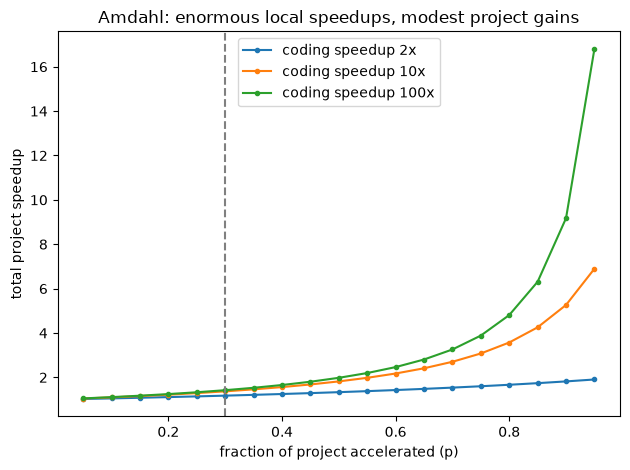

In [3]:
P = np.linspace(0.05, 0.95, 19)
fig, ax = plt.subplots()
for s in [2, 10, 100]:
    ax.plot(P, [amdahl(p, s) for p in P], marker="o", ms=3, label=f"coding speedup {s}x")
ax.axvline(0.30, ls="--", c="gray")
ax.set_xlabel("fraction of project accelerated (p)")
ax.set_ylabel("total project speedup")
ax.set_title("Amdahl: enormous local speedups, modest project gains")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Extension (model): what if acceleration increases rework?

In [4]:
def with_rework(p: float, s: float, rework: float) -> float:
    """rework: extra verification/integration cost as fraction of project."""
    return 1.0 / ((1 - p) + p / s + rework)

for r in [0.0, 0.1, 0.2]:
    print(f"rework={r:.1f}: total speedup = {with_rework(0.30, 100, r):.2f}x")
assert with_rework(0.30, 100, 0.2) < amdahl(0.30, 100)

rework=0.0: total speedup = 1.42x
rework=0.1: total speedup = 1.25x
rework=0.2: total speedup = 1.11x


## Interpretation
- Supports: project speedup is capped by the un-accelerated fraction; rework can erase local gains.
- Does NOT support: any empirical claim about AI coding tools; `p` and `rework` are yours to estimate.

## Try it yourself
1. Set `p=0.6` — what project fraction must be accelerable for 3x total?
2. Find the rework level that cancels a 100x coding speedup at your `p`.
3. Add a second accelerated fraction (e.g. review) and recompute.